# Challenge 2: Image Classification

## Module imports

In [ ]:
import hparams
import image_classifier

import os
import torch
torch.manual_seed(hparams.SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np


if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(hparams.SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


PyTorch version: 2.9.1+cpu
Device: cpu


## Image Loader

In [7]:
def load_images_from_folder(folder, cache_path):

    if os.path.exists(cache_path):
        print(f"Cache found at '{cache_path}'. Loading processed data...")
        return np.load(cache_path)

    print(f"Cache not found. Starting full image loading and preprocessing from '{folder}'...")
    
    images = []
    valid_extension = '.png'
    
    for filename in os.listdir(folder):
        if not filename.lower().endswith(valid_extension):
            continue
        
        file_path = os.path.join(folder, filename)
        img = cv2.imread(file_path)
        img = (img / 255.0).astype(np.float32)
        img = img[..., ::-1]
        
        h, w = img.shape[:2]

        if h > w:
            delta_w = h - w
            top, bottom = 0, 0
            left = delta_w // 2
            right = delta_w - left
        elif w > h:
            delta_h = w - h
            left, right = 0, 0
            top = delta_h // 2
            bottom = delta_h - top
        else:
            top, bottom, left, right = 0, 0, 0, 0

        img = cv2.copyMakeBorder(
            img, top, bottom, left, right, 
            cv2.BORDER_CONSTANT, 
            value=[0, 0, 0]
        )

        img = cv2.resize(img, (hparams.IMAGE_SIZE, hparams.IMAGE_SIZE))
        images.append(img)
        
        
    final_array = np.array(images)

    cache_dir = os.path.dirname(cache_path)
    if cache_dir and not os.path.exists(cache_dir):
        os.makedirs(cache_dir, exist_ok=True)
        print(f"Created cache directory: {cache_dir}")
    
    print(f"Finished preprocessing {len(final_array)} images. Saving to cache...")
    np.save(cache_path, final_array)
    
    return final_array

train_images = load_images_from_folder(hparams.TRAIN_DATA_PATH, hparams.TRAIN_CACHE_PATH)
print(f"Loaded {len(train_images)} images for training")


Cache not found. Starting full image loading and preprocessing from 'train_data'...
Loaded and processed 20 images...
Loaded and processed 40 images...
Loaded and processed 60 images...
Loaded and processed 80 images...
Loaded and processed 100 images...
Loaded and processed 120 images...
Loaded and processed 140 images...
Loaded and processed 160 images...
Loaded and processed 180 images...
Loaded and processed 200 images...
Loaded and processed 220 images...
Loaded and processed 240 images...
Loaded and processed 260 images...
Loaded and processed 280 images...
Loaded and processed 300 images...
Loaded and processed 320 images...
Loaded and processed 340 images...
Loaded and processed 360 images...
Loaded and processed 380 images...
Loaded and processed 400 images...
Loaded and processed 420 images...
Loaded and processed 440 images...
Loaded and processed 460 images...
Loaded and processed 480 images...
Loaded and processed 500 images...
Loaded and processed 520 images...
Loaded and

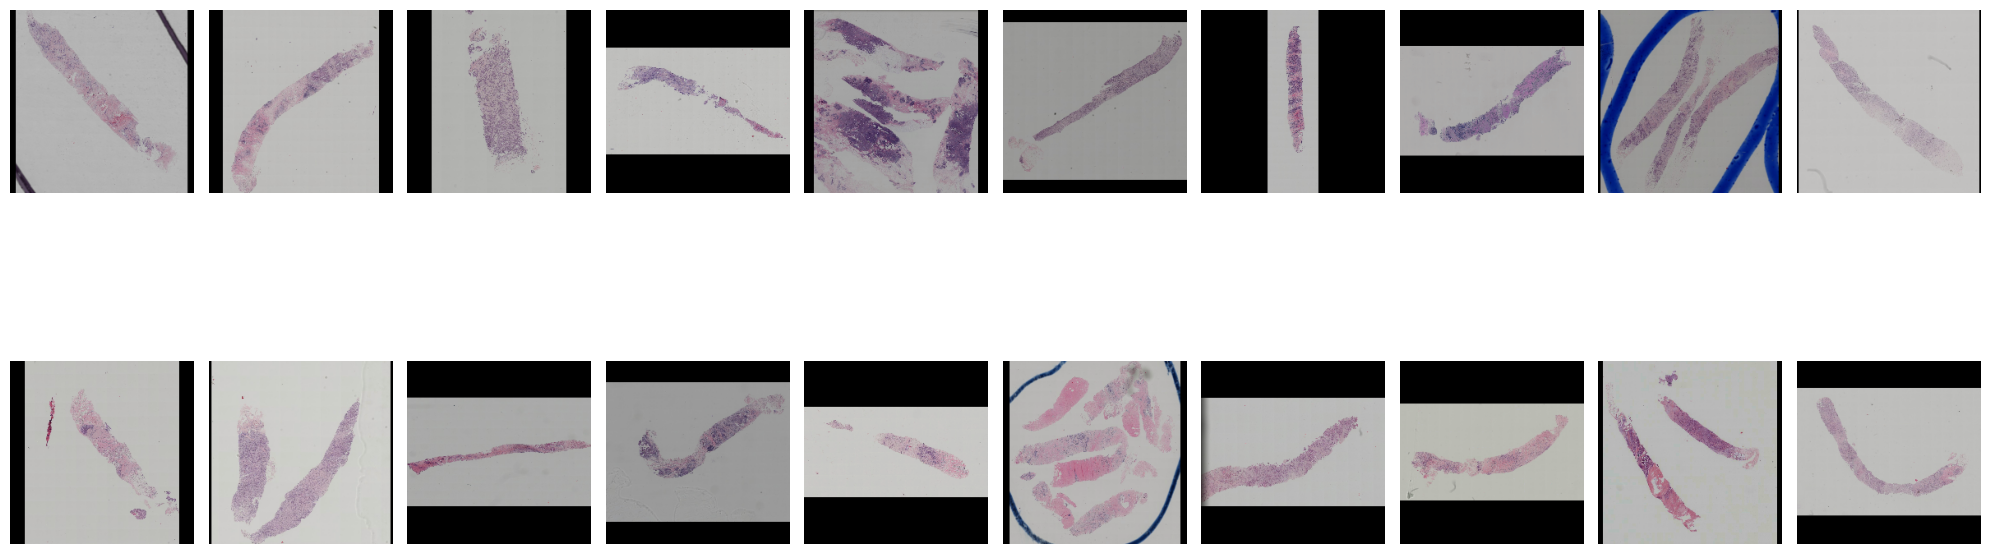

In [8]:
# Number of images to display
num_img = 20

fig, axes = plt.subplots(2, num_img//2, figsize=(20, 9))
for i in range(num_img):
    ax = axes[i%2, i%num_img//2]
    ax.imshow(np.clip(train_images[i], 0, 1)) 
    ax.axis('off')
plt.tight_layout()
plt.show()